In [1]:
# This script uses class definition to store, access and compute GP Observables in an organized manner

import GPKoopman as gpk
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, clear_output
import math

print('Imported PyTorch version:', torch.__version__)
print('Imported NumPy version:', np.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

Imported PyTorch version: 2.5.1+cu124
Imported NumPy version: 2.2.1
True
NVIDIA GeForce RTX 3060 Laptop GPU


### Testing Cells

In [2]:
def check_pd(matrix: torch.Tensor):
    """
    Checks if a given 2D PyTorch tensor is positive definite (PD) or 
    positive semi-definite (PSD) or neither.
    
    Args:
        matrix (torch.Tensor): A 2D square PyTorch tensor.

    Returns:
        str: "Positive Definite", "Positive Semi-Definite", or "Neither"
    """
    if not (matrix.dim() == 2 and matrix.shape[0] == matrix.shape[1]):
        raise ValueError("Input must be a square matrix")

    try:
        # Attempt Cholesky decomposition for positive definiteness
        torch.linalg.cholesky(matrix)
        return "Positive Definite"
    except RuntimeError:
        # Compute eigenvalues for semi-definiteness check
        eigenvalues = torch.linalg.eigvals(matrix)
        if torch.all(eigenvalues >= 0):
            return "Positive Semi-Definite"
        else:
            return "Neither"

### Cost Function Definition

In [3]:
# Multi-Trajectory Cost Function Definition

def get_cost_grid(Z, X, Xplus, Xtrain, manager, nT=1, lambda1=1.0, lambda2=1.0, lambda3=1.0):
    """
    Computes the cost function as defined in the Word doc, with different GP Kernel hyperparameters for
    each observable.

    Args:
        Z: Tensor of shape (r**n, p), decision variable, required grad
        X: Tensor of shape (n, nT*N), dataset of N steps from all trajectories
        Xall: Tensor of shape (n, nT*(N+1)), complete training dataset
        Xtrain: Tensor of shape (n, r**n), flattened set of gridpoints for training GPOs
        manager: Object of class GPObservablesManager (manager for all Gaussian Process based Observable functions)
        nT: float, number of trajectories in training dataset
        lambda1: float, Weighting for prediction error minimization term
        lambda2: float, Weightining for Reconstruction Error penalty term
    """
    
    N = (X.shape[1])//nT    # Number of time steps in each trajectory
    p = Z.shape[1]          # Number of Observables
    l = Z.shape[0]//nT      # Decision Horizon
    n = X.shape[0]          # Dimensionality of original system

    for i in range(p):
        manager.train_observable(i, Xtrain, Z[:,i])

    # For current definition of GPOs
    # Training: Xtrain = dimensions x samples
    # Training: Ytrain = samples x (dimensions=1)
    # Prediction: Xquery = dimensions x num-query = Input
    # Prediction: Yquery = num-query x (dimensions=1) = Output

    # Lifting X and Xplus to higher dimension using trained GPOs
    M = torch.empty((p,N*nT))
    Mplus = torch.empty((p,N*nT))
    
    #Mall = torch.empty((p,(N+1)*nT))
    for i in range(p):
        M[i,:] = torch.transpose(manager.predict_mean(i, X), dim0=0, dim1=-1)
        Mplus[i,:] = torch.transpose(manager.predict_mean(i, Xplus), dim0=0, dim1=-1)
    
    # Compute C(z) and A(z)
    Mfull = torch.vstack((X, M))
    Mplusfull = torch.vstack((Xplus, Mplus))

    M_pinv = torch.linalg.pinv(Mfull)
    #Cz = X @ M_pinv
    Az = Mplusfull @ M_pinv
    C = torch.zeros((n,n+p))
    for i in range(n):
        C[i,i] = 1.
    
    # Cost term 1: Multi-Trajectory Prediction Error Minimization
    NormPEM = 0.0
    for j in range(nT):
        TrajPEM = 0.0
        for k in range(N - 1):
            pred_error = X[:, j*N + (k+1)] - C @ (torch.linalg.matrix_power(Az,k+1)) @ Mfull[:,j*N]   # multi-step at X (with Cz)
            TrajPEM += torch.norm(pred_error)
        NormPEM += TrajPEM
    
    # Linearity Enforcement
    NormLEP = 0.0
    for j in range(nT):
        TrajLEP = 0.0
        for k in range(l-1):
            Zk = torch.vstack([X[:, j*N + k].view(n,1), torch.transpose(Z[j*l + k, :], dim0=0, dim1=-1).view(p,1)])
            Zkplus = torch.vstack([X[:, j*N + k + 1].view(n,1), torch.transpose(Z[j*l + k + 1, :], dim0=0, dim1=-1).view(p,1)])
            lin_error = Zkplus - Az @ Zk
            TrajLEP += torch.norm(lin_error)
        NormLEP += TrajLEP
    
    # Weighted sum of terms
    cost = (lambda1 * NormPEM / (N * nT)) + (lambda2 * NormLEP / (l * nT))
    return cost

def get_cost_AC(Z, X, Xplus, Xtrain, manager, nT=1, lambda1=1.0, lambda2=1.0, lambda3=1.0):
    """
    Computes the cost function as defined in the Word doc, with different GP Kernel hyperparameters for
    each observable.

    Args:
        Z: Tensor of shape (r**n, p), decision variable, required grad
        X: Tensor of shape (n, nT*N), dataset of N steps from all trajectories
        Xall: Tensor of shape (n, nT*(N+1)), complete training dataset
        Xtrain: Tensor of shape (n, r**n), flattened set of gridpoints for training GPOs
        manager: Object of class GPObservablesManager (manager for all Gaussian Process based Observable functions)
        nT: float, number of trajectories in training dataset
        lambda1: float, Weighting for NLPD
        lambda2: float, Weightining for Linearity enforcement in lifted state
    """
    
    N = (X.shape[1])//nT    # Number of time steps in each trajectory
    p = Z.shape[1]          # Number of Observables
    l = Z.shape[0]//nT      # Decision Horizon
    n = X.shape[0]          # Dimensionality of original system

    for i in range(p):
        manager.train_observable(i, Xtrain, Z[:,i])

    # Lifting X and Xplus to higher dimension using trained GPOs
    M = torch.empty((p,N*nT))
    Mplus = torch.empty((p,N*nT))
    
    #Mall = torch.empty((p,(N+1)*nT))
    for i in range(p):
        M[i,:] = torch.transpose(manager.observables[i].forward_mean(X), dim0=0, dim1=-1)
        Mplus[i,:] = torch.transpose(manager.observables[i].forward_mean(Xplus), dim0=0, dim1=-1)
    
    # Compute C(z) and A(z)
    M_pinv = torch.linalg.pinv(M)
    Cz = X @ M_pinv
    Az = Mplus @ M_pinv
        
    # Cost term 1: Negative Log Predictive Density (penalize uncertainty and confidently wrong models)
    NormNLPD = 0.0
    for j in range(nT):
        TrajNLPD = 0.0
        vz_k = torch.empty((p,N - 2 - l), device=M.device)
        for i in range(p):
            vz_k[i, :] = torch.clamp(torch.diag(manager.observables[i].forward_cov(X[:, j*N + l + 1:(j+1)*N-1])).view(1,N-2-l), min=1e-6)

        for k in range(N-2-l):        
            vx_next = torch.diag(Cz @ Az @ torch.diag(vz_k[:, k]) @ Az.T @ Cz.T).view(n,1)
            #vx_next = torch.clamp(vx_next, min=1e-8)  # Ensure positivity
            error_term = ((X[:, j*N + l+1 + k+1] - Cz @ Az @ M[:, j*N + l+1 + k]) ** 2) / (lambda3 + vx_next)
            log_term = torch.log(lambda3 + vx_next)
            # Sum the contributions from all dimensions
            TrajNLPD += torch.sum(error_term + log_term)


        NormNLPD += TrajNLPD

    # Cost Term 2: Linearity Enforcement
    NormLEP = 0.0
    for j in range(nT):
        TrajLEP = 0.0
        for k in range(l-1):
            lin_error = torch.transpose(Z[j*l + k + 1, :], dim0=0, dim1=-1) - Az @ torch.transpose(Z[j*l + k, :], dim0=0, dim1=-1)
            TrajLEP += torch.norm(lin_error)
        NormLEP += TrajLEP
    
    # Weighted sum of terms
    cost = (lambda1 * NormNLPD / ((N-l) * nT)) + (lambda2 * NormLEP / (l * nT))
    return cost

# Execution Cells

## Data Loading

In [4]:
# Allowed system names -
# "Unforced Duffing"
# "Unforced Duffing"_right - domain restricted to right equilibrium point only
# "van der Pol"
# "Simple Pendulum"
# "Lorenz"
# "Lotka Volterra"
# "Piecewise Linear"

system_name = 'Piecewise Linear'
data = torch.load(f"Data/DataAuto_{system_name}.pt", weights_only=True)

SimData = data["trajectories"] # Shape: (num_trajectories, state_dim, num_steps)
ts = data["sample_time"]
num_trajectories = data["num_trajectories"]
N = data["num_steps"]
nTrain = math.floor(num_trajectories * 0.3)
nTest = math.floor(num_trajectories * 0.2)
# SimData = SimData[:,:,:101]
# N = 100

In [5]:
# # Create a 3D figure
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111, projection='3d')

# # Plot all trajectories
# for i in range(num_trajectories):
#     ax.plot(SimData[i, 0, :], SimData[i, 1, :], SimData[i, 2, :], alpha=0.7, label=f'Traj {i+1}' if i < 5 else "")
#     ax.plot(SimData[i, 0, 0], SimData[i, 1, 0], SimData[i, 2, 0], alpha=0.7, marker='o', linestyle='None')

# # Labels and title
# ax.set_xlabel("State X1")
# ax.set_ylabel("State X2")
# ax.set_zlabel("State X3")
# ax.set_title("3D Plot of All Trajectories in SimData")

# plt.show()

## Optimization Section

### Find Optimal Z Values

In [6]:
SimData = SimData.float()
n = SimData.shape[1]

p = 10  # number of lifted states
l = 10  # decision horizon for each lifted state
r = 10   # resolution along all dimensions

Xall = torch.cat([SimData[j, :, :] for j in range(nTrain)], dim=1)      # Concatenated total matrix
X = torch.cat([SimData[j, :, 0:N] for j in range(nTrain)], dim=1)       # Concatenated Data matrix
Xplus = torch.cat([SimData[j, :, 1:] for j in range(nTrain)], dim=1)    # Time-shifted Data matrix
ICsetTrain = torch.cat([SimData[j, :, 0].view(n,1) for j in range(nTrain)], dim=1)    # Random IC set for training
ICsetTest = torch.cat([SimData[j, :, 0].view(n,1) for j in range(nTrain, nTrain + nTest)], dim=1)  # Random IC set for testing

# Options: 'Horizon' | 'Grid'
trainMethod = 'Horizon'

# Initialize GP training-grid and decision variables
if trainMethod == 'Horizon':
    Xtrain = torch.cat([X[:,j*N:j*N+l] for j in range(nTrain)],dim=1)
    #Z = torch.rand(Xtrain.shape[1], p, requires_grad=True)
    Z = torch.nn.Parameter(torch.rand(Xtrain.shape[1], p))
    ObsManager = gpk.GPObservablesManager()
    for i in range(p):
        ObsManager.add_observable(index=i, d=n, ns=l*nTrain, kernel_types=['Gaussian'], combination='sum',noise=1e-6, m=500)
        
elif trainMethod == 'Grid':
    # GPO Training Grid
    gridpoints0 = torch.linspace(-4., 4., steps=r)
    gridpoints1 = torch.linspace(-4., 4., steps=r)
    grid0, grid1 = torch.meshgrid(gridpoints0, gridpoints1, indexing='xy')
    Xtrain = torch.stack([torch.flatten(grid0), torch.flatten(grid1)])
    Z = torch.rand(r**n, p, requires_grad=True)
    ObsManager = gpk.GPObservablesManager()
    for i in range(p):
        ObsManager.add_observable(index=i, d=n, ns=r**n, kernel_types=['Gaussian', 'ExplicitAttractor'], combination='product', noise=1e-6)

else:
    raise ValueError(f'Unrecognized GP Training method {trainMethod}')

ObsManager.set_random_hyperparameters(scale=[1., 0.01, 0.])
print('Observable Hyperparameters have been randomized')

Observable Hyperparameters have been randomized


In [7]:
# Plot the Xtrain points in space
if Xtrain.shape[0] >= 2:
    for i in range(Xtrain.shape[1]):
        plt.plot(Xtrain[0,i], Xtrain[1,i], linestyle='None', marker='x', color='red', alpha=0.5)
    plt.xlabel('X1'), plt.ylabel('X2'), plt.grid()
    plt.title('Inducing Points (Xtrain)')
    plt.show()


In [8]:
cost1 = get_cost_AC(Z, X, Xplus, Xtrain, ObsManager, nT=nTrain, lambda1=1., lambda2=0., lambda3=0.)
cost2 = get_cost_AC(Z, X, Xplus, Xtrain, ObsManager, nT=nTrain, lambda1=0., lambda2=1., lambda3=0.)
print(f'Initial Cost-1 is {cost1.cpu().detach()}')
print(f'Initial Cost-2 is {cost2.cpu().detach()}')


Initial Cost-1 is 204794.640625
Initial Cost-2 is 1.0019936561584473


In [9]:
ObsManager.print_parameters()

Index | Kernel Types | Noise     | hp1       | hp2       | mu       
--------------------------------------------------------------------
0     | Gaussian     | 1.000e-06 | 6.130e-01 | 9.877e-03 | 0.000e+00
1     | Gaussian     | 1.000e-06 | 7.296e-01 | 3.264e-03 | 0.000e+00
2     | Gaussian     | 1.000e-06 | 2.255e-01 | 3.584e-03 | 0.000e+00
3     | Gaussian     | 1.000e-06 | 2.663e-01 | 5.246e-03 | 0.000e+00
4     | Gaussian     | 1.000e-06 | 3.806e-01 | 2.197e-03 | 0.000e+00
5     | Gaussian     | 1.000e-06 | 7.428e-01 | 9.205e-03 | 0.000e+00
6     | Gaussian     | 1.000e-06 | 6.813e-01 | 3.281e-03 | 0.000e+00
7     | Gaussian     | 1.000e-06 | 3.767e-01 | 9.150e-03 | 0.000e+00
8     | Gaussian     | 1.000e-06 | 2.217e-01 | 7.364e-03 | 0.000e+00
9     | Gaussian     | 1.000e-06 | 6.967e-01 | 4.421e-03 | 0.000e+00


In [10]:
#print(f'Total Observables available: {gpk.GPObservable.count_Observables()}')

# Optimization Parameters
max_iter = 500
learn_rate = 0.001   # Learning Rate    
err_thresh = 0.01    # Target Cost
patience = 10       # Number of iterations to monitor for significant change
min_delta = 5e-1    # Minimum required decrease in cost for significance

# optimizer = torch.optim.Adam([Z] + list(ObsManager.parameters(get_mu_only=True)), lr=learn_rate)
optimizer = torch.optim.Adam([Z], lr=learn_rate)


print('Starting Iteration Loop!')
cost_history = []
iter = 0
count_insignificant = 0

while iter < max_iter:
    optimizer.zero_grad()  # Clear gradients
    cost = get_cost_AC(Z, X, Xplus, Xtrain, ObsManager, nT=nTrain, lambda1=1e-3, lambda2=1., lambda3=0.)   # compute cost
    cost_history.append(cost.item())    # add to cost history
    cost.backward(retain_graph=True)    # backpropagate
    # torch.nn.utils.clip_grad_norm_([Z], max_norm=100.)
    # torch.nn.utils.clip_grad_norm_(list(ObsManager.parameters(get_mu_only=True)), max_norm=100.)
    optimizer.step()    # gradient descent step
    # for p in ObsManager.parameters(get_mu_only=True):
    #     print(p.grad)
    # print(Z.grad)
    print(f"Iteration {iter + 1}/{max_iter} with {count_insignificant} Insignificant Iterations")
    print(f"Cost: {cost.item()}")

    # Stopping conditions
    if cost.item() < err_thresh:
        print("Stopping: Error threshold reached.")
        break

    # Check for significant improvement
    if iter > patience:
        error_change = cost_history[-patience] - cost_history[-1]
        if error_change < min_delta or error_change < 0:
            count_insignificant += 1
        else:
            count_insignificant = 0

        if count_insignificant >= patience:
            print("Stopping: No significant improvement over consecutive iterations.")
            break

    # Increment iteration
    iter += 1

if iter == max_iter:
    print(f'Stopping: Reached maximum number of iterations = {iter}.')


optimal_Z = Z.detach()

print('Optimization Complete.')
print("Final Cost:", cost.item())

Starting Iteration Loop!
Iteration 1/500 with 0 Insignificant Iterations
Cost: 205.79664611816406
Iteration 2/500 with 0 Insignificant Iterations
Cost: 195.12855529785156
Iteration 3/500 with 0 Insignificant Iterations
Cost: 184.33590698242188
Iteration 4/500 with 0 Insignificant Iterations
Cost: 173.6604766845703
Iteration 5/500 with 0 Insignificant Iterations
Cost: 163.28797912597656
Iteration 6/500 with 0 Insignificant Iterations
Cost: 153.36509704589844
Iteration 7/500 with 0 Insignificant Iterations
Cost: 144.0009307861328
Iteration 8/500 with 0 Insignificant Iterations
Cost: 135.25173950195312
Iteration 9/500 with 0 Insignificant Iterations
Cost: 127.13623809814453
Iteration 10/500 with 0 Insignificant Iterations
Cost: 119.66111755371094
Iteration 11/500 with 0 Insignificant Iterations
Cost: 112.79773712158203
Iteration 12/500 with 0 Insignificant Iterations
Cost: 106.51759338378906
Iteration 13/500 with 0 Insignificant Iterations
Cost: 100.77786254882812
Iteration 14/500 with 0 

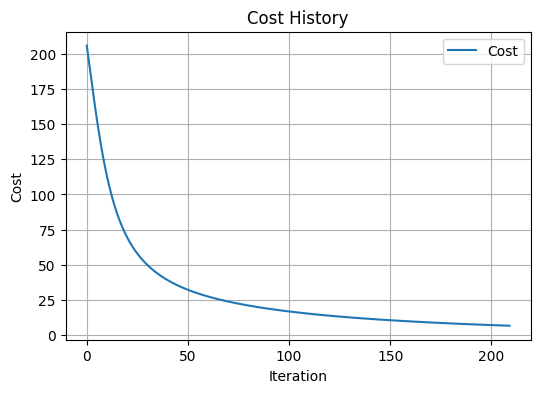

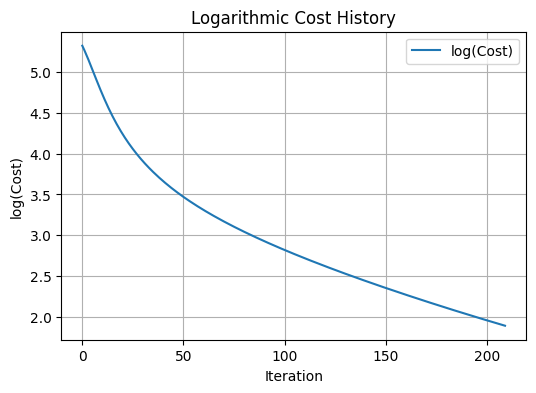

In [11]:
# Cost Plotting
# Plot cost history
plt.figure(figsize=(6,4))
plt.plot(cost_history, label="Cost")
plt.title("Cost History")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.grid()
plt.show()

# Logarithmic cost history
plt.figure(figsize=(6,4))
plt.plot(torch.log(torch.tensor(cost_history)), label="log(Cost)")
plt.title("Logarithmic Cost History")
plt.xlabel("Iteration")
plt.ylabel("log(Cost)")
plt.legend()
plt.grid()
plt.show()

In [12]:
ObsManager.print_parameters()

Index | Kernel Types | Noise     | hp1       | hp2       | mu       
--------------------------------------------------------------------
0     | Gaussian     | 1.000e-06 | 6.130e-01 | 9.877e-03 | 0.000e+00
1     | Gaussian     | 1.000e-06 | 7.296e-01 | 3.264e-03 | 0.000e+00
2     | Gaussian     | 1.000e-06 | 2.255e-01 | 3.584e-03 | 0.000e+00
3     | Gaussian     | 1.000e-06 | 2.663e-01 | 5.246e-03 | 0.000e+00
4     | Gaussian     | 1.000e-06 | 3.806e-01 | 2.197e-03 | 0.000e+00
5     | Gaussian     | 1.000e-06 | 7.428e-01 | 9.205e-03 | 0.000e+00
6     | Gaussian     | 1.000e-06 | 6.813e-01 | 3.281e-03 | 0.000e+00
7     | Gaussian     | 1.000e-06 | 3.767e-01 | 9.150e-03 | 0.000e+00
8     | Gaussian     | 1.000e-06 | 2.217e-01 | 7.364e-03 | 0.000e+00
9     | Gaussian     | 1.000e-06 | 6.967e-01 | 4.421e-03 | 0.000e+00


### Post-Process Optimization Results

In [13]:
# Use Optimal Z values to Build GP Models and Optimal A and Z matrices
optimal_Z = Z.detach()
for i in range(p):
    ObsManager.train_observable(i, Xtrain, optimal_Z[:,i])  # train GP Observables with Optimal Z outputs

#ObsManager.optimize_hyperparameters(opt_mu=False)   # Optimize Kernel hyperparameters for Optimal training data

#ObsManager.plot_observables(range_x=(-3,3), range_y=(-3,3))

ObsList = [i for i in range(p)]
A, C = gpk.getKoopman(ObsManager, ObsList, Xall, nTrain, stateAug=False)

## Simulation and Validation

In [14]:
# Evaluation on training set
ZmeanTrain = torch.empty((nTrain, p, N))    # n+p for state-augmentation
ZcvTrain = torch.empty((nTrain, p, p, N))   # n for no state-augmentation
#ZmeanTrain[:, :n, 0] = ICsetTrain.T    # only for state-augmentation

XhatTrain = torch.empty((nTrain, n, N))
XcvhatTrain = torch.empty((nTrain, n, n, N))
TrainRMSE = torch.empty((nTrain,n))

for j in range(nTrain): # GP Predict for all training trajectories
    for i in range(p):  # GP predict IC and IC-cv
        ZmeanTrain[j, i, 0] = ObsManager.predict_mean(i, ICsetTrain[:, j].view(n,1))        # n+i for state-augmentation
        ZcvTrain[j, i, i, 0] = ObsManager.predict_covariance(i, ICsetTrain[:, j].view(n,1)) # n for no state-augmentation
    
    ZmeanTrain[j, :, :], ZcvTrain[j, :, :, :], XhatTrain[j, :, :], XcvhatTrain[j, :, :, :] = gpk.sim_LTI(ZmeanTrain[j,:,0], A, C, num_steps=N, ts=None, x0cv=ZcvTrain[j,:,:,0])
    TrainRMSE[j,:] = torch.sqrt(torch.mean((XhatTrain[j,:,:] - SimData[j,:,:N])**2,1))


# Evaluation on test set
ZmeanTest = torch.empty((nTest, p, N))
ZcvTest = torch.empty((nTest, p, p, N))
#ZmeanTest[:, :n, 0] = ICsetTest.T  # only for state-augmentation

XhatTest = torch.empty((nTest, n, N))
XcvhatTest = torch.empty((nTest, n, n, N))
TestRMSE = torch.empty((nTest,n))

for j in range(nTest): # GP Predict for all training trajectories
    for i in range(p):  # GP predict IC and IC-cv
        ZmeanTest[j, i, 0] = ObsManager.predict_mean(i, ICsetTest[:, j].view(n,1))          # n+i for state-augmentation
        ZcvTest[j, i, i, 0] = ObsManager.predict_covariance(i, ICsetTest[:, j].view(n,1))   # n for no state-augmentation

    ZmeanTest[j, :, :], ZcvTest[j, :, :, :], XhatTest[j, :, :], XcvhatTest[j, :, :, :] = gpk.sim_LTI(ZmeanTest[j,:,0], A, C, num_steps=N, ts=None, x0cv=ZcvTest[j,:,:,0])
    TestRMSE[j,:] = torch.sqrt(torch.mean((XhatTest[j,:,:] - SimData[nTest+j,:,:N])**2,1))

XhatTrain, XhatTest, XcvhatTrain, XcvhatTest = XhatTrain.detach(), XhatTest.detach(), XcvhatTrain.detach(), XcvhatTest.detach()
TestRMSE, TrainRMSE = TestRMSE.detach(), TrainRMSE.detach()

In [15]:
# Function to compute RMSE, NLPD, and sRMSE
def compute_metrics(Xhat, Xcvhat, SimData, nTraj, N, eps=1e-6):
    RMSE = torch.sqrt(torch.mean((Xhat - SimData[:nTraj, :, :N]) ** 2, dim=2))
    
    #var_diag = Xcvhat.diagonal(dim1=1, dim2=2).permute(0, 2, 1)  # Shape (nTraj, n, N)
    
    #NLPD = torch.mean(0.5 * ((SimData[:nTraj, :, :N] - Xhat) ** 2 / var_diag + torch.log(2 * torch.pi * var_diag)), dim=2)
    
    #sRMSE = torch.sqrt(torch.mean(((SimData[:nTraj, :, :N] - Xhat) / var_diag.sqrt()) ** 2, dim=2))

    return RMSE

time = torch.arange(0., ts * N, ts)
idx1 = torch.argmin(TrainRMSE.mean(dim=1))
idx2 = torch.argmin(TestRMSE.mean(dim=1))
idx3 = torch.argmax(TestRMSE.mean(dim=1))

# Best Training Trajectory Phase Plot
plt.figure(1, figsize=(6,4.5))
plt.plot(XhatTrain[idx1, 0, :], XhatTrain[idx1, 1, :], label='iGPK')
plt.plot(SimData[idx1, 0, :N], SimData[idx1, 1, :N], label='Nonlinear', linestyle='--')
plt.plot(ICsetTrain[0, idx1], ICsetTrain[1, idx1], label='IC', marker='o')
plt.title(f"Validation on Training Trajectory for {system_name}")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid()
plt.show()


fig, axes = plt.subplots(n, 1, figsize=(6, 5))  # Increased figure height for better spacing
idx = idx1
fig.suptitle(f'{system_name}: States in Training with $1\\sigma$ bound')
for i in range(n):
    axes[i].fill_between(time, XhatTrain[idx, i, :] - XcvhatTrain[idx, i, i, :] ** 0.5, 
                    XhatTrain[idx, i, :] + XcvhatTrain[idx, i, i, :] ** 0.5, 
                    alpha=0.16, color='blue') #, label='$\\sigma$'
    # axes[i].fill_between(time, XhatTrain[idx, i, :] - 3 * XcvhatTrain[idx, i, i, :] ** 0.5, 
    #                 XhatTrain[idx, i, :] + 3 * XcvhatTrain[idx, i, i, :] ** 0.5, 
    #                 alpha=0.08, color='blue', label=f'$3\\sigma$')
    axes[i].plot(time, XhatTrain[idx, i,:], label=f'iGPK', color='blue')
    axes[i].plot(time, SimData[idx, i, :N], label=f'NL', linestyle='--', color='red')
    axes[i].set_ylabel(f'State X{i+1}')
    axes[i].legend()
    axes[i].grid()
    if i < n - 1:
        axes[i].set_xticklabels([])  # Hide x-axis labels for all but the last subplot

axes[-1].set_xlabel('Time [s]')  # Set x-label only for the bottom subplot
plt.tight_layout()
plt.show()


# Best Test Trajectory Plot
plt.figure(3,figsize=(6,4.5))
plt.plot(XhatTest[idx2, 0, :], XhatTest[idx2, 1, :], label='iGPK')
plt.plot(SimData[nTrain+idx2, 0, :N], SimData[nTrain+idx2, 1, :N], label='Nonlinear', linestyle='--')
plt.plot(ICsetTest[0, idx2], ICsetTest[1,idx2], label='IC', marker='o')
plt.title(f"Validation on Test Trajectory for {system_name}")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid()
plt.show()


# Best Test Trajectory Time Plot with uncertainty bound
fig, axes = plt.subplots(n, 1, figsize=(6, 5))  # Increased figure height for better spacing
idx = idx2
fig.suptitle(f'{system_name}: States in Test with $1\\sigma$ bound')
for i in range(n):
    axes[i].fill_between(time, XhatTest[idx, i, :] - XcvhatTrain[idx, i, i, :] ** 0.5, 
                    XhatTest[idx, i, :] + XcvhatTrain[idx, i, i, :] ** 0.5, 
                    alpha=0.16, color='blue') #, label='$\\sigma$'
    # axes[i].fill_between(time, XhatTest[idx, i, :] - 3 * XcvhatTest[idx, i, i, :] ** 0.5, 
    #                 XhatTest[idx, i, :] + 3 * XcvhatTest[idx, i, i, :] ** 0.5, 
    #                 alpha=0.08, color='blue') #, label=f'$3\\sigma$'
    axes[i].plot(time, XhatTest[idx, i,:], label=f'iGPK', color='blue')
    axes[i].plot(time, SimData[nTrain+idx, i, :N], label=f'NL', linestyle='--', color='red')
    axes[i].set_ylabel(f'State X{i+1}')
    axes[i].legend(), axes[i].grid()
    if i < n - 1:
        axes[i].set_xticklabels([])  # Hide x-axis labels for all but the last subplot

axes[-1].set_xlabel('Time [s]')  # Set x-label only for the bottom subplot
plt.tight_layout()
plt.show()


# Worst Test Trajectory Plot
plt.figure(3,figsize=(6,4.5))
plt.plot(XhatTest[idx3, 0, :], XhatTest[idx3, 1, :], label='iGPK')
plt.plot(SimData[nTrain+idx3, 0, :N], SimData[nTrain+idx3, 1, :N], label='Nonlinear', linestyle='--')
plt.plot(ICsetTest[0, idx3], ICsetTest[1,idx3], label='IC', marker='o')
plt.title(f"Validation on Worst Test Trajectory for {system_name}")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid()
plt.show()


# Worst Test Trajectory Time Plot with uncertainty bound
fig, axes = plt.subplots(n, 1, figsize=(6, 5))  # Increased figure height for better spacing
idx = idx3
fig.suptitle(f'{system_name}: States with $1\\sigma$ bound: Worst Test Trajectory')
for i in range(n):
    axes[i].fill_between(time, XhatTest[idx, i, :] - XcvhatTrain[idx, i, i, :] ** 0.5, 
                    XhatTest[idx, i, :] + XcvhatTrain[idx, i, i, :] ** 0.5, 
                    alpha=0.16, color='blue') #, label='$\\sigma$'
    # axes[i].fill_between(time, XhatTest[idx, i, :] - 3 * XcvhatTest[idx, i, i, :] ** 0.5, 
    #                 XhatTest[idx, i, :] + 3 * XcvhatTest[idx, i, i, :] ** 0.5, 
    #                 alpha=0.08, color='blue') #, label=f'$3\\sigma$'
    axes[i].plot(time, XhatTest[idx, i,:], label=f'iGPK', color='blue')
    axes[i].plot(time, SimData[nTrain+idx, i, :N], label=f'NL', linestyle='--', color='red')
    axes[i].set_ylabel(f'State X{i+1}')
    axes[i].legend(), axes[i].grid()
    if i < n - 1:
        axes[i].set_xticklabels([])  # Hide x-axis labels for all but the last subplot

axes[-1].set_xlabel('Time [s]')  # Set x-label only for the bottom subplot
plt.tight_layout()
plt.show()


IndexError: index 1 is out of bounds for dimension 1 with size 1

<Figure size 600x450 with 0 Axes>

In [ ]:

fig, axes = plt.subplots(n, 1, figsize=(6, 5))
idx = idx3
fig.suptitle(f'Predicted SD & |Error| for Worst Test Trajectory ({idx})')
for i in range(n):
    axes[i].plot(torch.abs(XcvhatTest[idx, i, i, :N-1]) ** 0.5, label='$\\sigma_X$', color='blue')
    axes[i].plot(torch.abs(SimData[nTrain+idx, i, :N-1] - XhatTest[idx, i, :N-1]), label='$\\epsilon_X$', color='red', linestyle='--')
    axes[i].set_ylabel(f'X{i+1}')
    axes[i].grid()
    axes[i].legend()
    if i < n - 1:
        axes[i].set_xticklabels([])  # Hide x-axis labels for all but the last subplot

axes[-1].set_xlabel('Time Step')  # Set x-label only for the bottom subplot
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(n, 1, figsize=(6, 5))
idx = idx2
fig.suptitle(f'Predicted SD & |Error| for Best Test Trajectory ({idx})')
for i in range(n):
    axes[i].plot(torch.abs(XcvhatTest[idx, i, i, :N-1]) ** 0.5, label='$\\sigma_X$', color='blue')
    axes[i].plot(torch.abs(SimData[nTrain+idx, i, :N-1] - XhatTest[idx, i, :N-1]), label='$\\epsilon_X$', color='red', linestyle='--')
    axes[i].set_ylabel(f'X{i+1}')
    axes[i].grid()
    axes[i].legend()
    if i < n - 1:
        axes[i].set_xticklabels([])  # Hide x-axis labels for all but the last subplot

axes[-1].set_xlabel('Time Step')  # Set x-label only for the bottom subplot
plt.tight_layout()
plt.show()


# Plot Predicted Standard Deviation and Actual Error for best Test Trajectory on log scale
plt.plot(torch.log(XcvhatTest[idx3, 0, 0, :N-1] ** 0.5), label='$\\sigma_{X1}$', color='blue')
plt.plot(torch.log(XcvhatTest[idx3, 1, 1, :N-1] ** 0.5), label='$\\sigma_{X2}$', color='red')
plt.plot(torch.log(torch.abs(SimData[nTrain+idx3, 0, :N-1] - XhatTest[idx3, 0, :N-1])), label='$\\epsilon_{X1}$', color='blue', linestyle='--')
plt.plot(torch.log(torch.abs(SimData[nTrain+idx3, 1, :N-1] - XhatTest[idx3, 1, :N-1])), label='$\\epsilon_{X2}$', color='red', linestyle='--')
plt.title(f'Predicted SD and |Error| for Worst Test Trajectory ({idx3}) on log scale')
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('Time Step')
plt.ylabel('log(X)')
plt.show()

In [ ]:
# Plot Errors for all trajectories
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Training set plot
axes[0].plot(range(nTrain), TrainRMSE[:,0].numpy(), marker='o', linestyle='-', label='RMSE X1')
axes[0].plot(range(nTrain), TrainRMSE[:,1].numpy(), marker='o', linestyle='-', label='RMSE X2')
#axes[0].plot(range(nTrain), TrainNLPD.mean(dim=1).numpy(), marker='s', linestyle='-', label='NLPD')
#axes[0].plot(range(nTrain), TrainsRMSE.mean(dim=1).numpy(), marker='^', linestyle='-', label='sRMSE')
axes[0].set_title('Training Metrics')
axes[0].set_xlabel("Trajectory Index")
axes[0].set_ylabel("Metric Value")
axes[0].legend()
axes[0].grid()

# Test set plot
axes[1].plot(range(nTest), TestRMSE[:,0].numpy(), marker='o', linestyle='-', label='RMSE X1')
axes[1].plot(range(nTest), TestRMSE[:,1].numpy(), marker='o', linestyle='-', label='RMSE X2')
#axes[1].plot(range(nTest), TestNLPD.mean(dim=1).numpy(), marker='s', linestyle='-', label='NLPD')
#axes[1].plot(range(nTest), TestsRMSE.mean(dim=1).numpy(), marker='^', linestyle='-', label='sRMSE')
axes[1].set_title('Test Metrics')
axes[1].set_xlabel("Trajectory Index")
axes[1].set_ylabel("Metric Value")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

In [ ]:
# Eigen value plot of Koopman Matrices
eigval = torch.linalg.eigvals(A)

eigreal = eigval.real
eigimag = eigval.imag

eigreal = eigreal.detach().numpy()
eigimag = eigimag.detach().numpy()

theta = np.linspace(0, 2*np.pi, 500)
unitCirclex = np.cos(theta)
unitCircley = np.sin(theta)


fig, axes = plt.subplots(1, 2, figsize=(8, 4))
# First subplot: Eigenvalues plot
axes[0].plot(unitCirclex, unitCircley, color='red', label='Unit Circle')
axes[0].scatter(eigreal, eigimag, color='blue', label='Eigenvalues')
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].axvline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_title(f"Eigenvalues of A Matrix with {p} Observables")
axes[0].set_xlabel("Real Part")
axes[0].set_ylabel("Imaginary Part")
axes[0].grid(True)
axes[0].legend(loc='upper right')

# Second subplot: Heatmap of matrix A
im = axes[1].imshow(A.detach().numpy(), cmap='viridis', aspect='auto')
fig.colorbar(im, ax=axes[1], label="Value")
axes[1].set_title(f'{A.shape[0]}-D Koopman Matrix')
axes[1].set_xlabel("Columns")
axes[1].set_ylabel("Rows")
plt.tight_layout()
plt.show()

In [ ]:
# Phase Diagram from all IC simulation
for j in range(SimData.shape[0]):
    plt.plot(SimData[j,0,:], SimData[j,1,:], alpha=0.5, color='blue')
    plt.plot(SimData[j,0,0], SimData[j,1,0], 'o', color='red')

plt.grid()
plt.xlabel('X1')
plt.ylabel('X2')
plt.title(f'All Trajectories: {system_name}')
plt.show()

# Training Set Predicted Trajectories
for j in range(XhatTrain.shape[0]):
    plt.plot(XhatTrain[j,0,:], XhatTrain[j,1,:], alpha=0.5, color='blue')
    plt.plot(XhatTrain[j,0,0], XhatTrain[j,1,0], 'o', color='red')

plt.grid()
plt.xlabel('X1')
plt.ylabel('X2')
plt.title(f'Predicted Trajectories - Training Set: {system_name}')
plt.show()


In [ ]:
# # Create a 3D figure
# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111, projection='3d')

# # Plot all trajectories
# for i in range(XhatTrain.shape[0]):
#     ax.plot(XhatTrain[i, 0, :], XhatTrain[i, 1, :], XhatTrain[i, 2, :], alpha=0.7, label=f'Traj {i+1}' if i < 5 else "")
#     ax.plot(XhatTrain[i, 0, 0], XhatTrain[i, 1, 0], XhatTrain[i, 2, 0], alpha=0.7, marker='o', linestyle='None')

# # Labels and title
# ax.set_xlabel("State X1")
# ax.set_ylabel("State X2")
# ax.set_zlabel("State X3")
# ax.set_title("3D Plot of All Trajectories from iGPK Model")